# Agent Orchestration: Single Agent State Machine

Welcome to Module 04! Before we build teams of agents, we must master the **Graph Architecture** for a single agent. 

## 1. Why LangGraph?
In Module 01, we built a ReAct agent using simple loops. However, production agents are complex. They need to:
- **Handle Cycles**: Retry a search if it fails.
- **Maintain State**: Keep track of what has been tried.
- **Persistence**: Save the agent's progress so it can resume later.

**LangGraph** allows us to define an agent as a **State Machine** (a finite graph).

---

## 2. The Core Concepts
1. **State**: A shared memory that all parts of the graph can read/write to.
2. **Nodes**: Python functions that perform work (e.g., "Call LLM", "Run Tool").
3. **Edges**: The arrows connecting nodes. They define the flow logic (e.g., "If LLM wants tool -> Go to Tools Node").

---

## 3. Environment Setup
We need `langgraph` and our standard Gemini setup.

In [1]:
import os
from typing import Annotated, TypedDict, Union, List
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("LangGraph Environment Ready!")

/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:234: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with cri

LangGraph Environment Ready!


## 4. Defining the Agent's State
The **State** is the "brain" of our graph. Here, we simply track a list of messages.

In [2]:
class AgentState(TypedDict):
    # Annotated with operator.add means messages will be appended, not overwritten
    # This is how LangGraph maintains history automatically
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]

## 5. Defining Tools
Let's create a simple tool for our single agent to use.

In [3]:
@tool
def get_weather(city: str):
    """Get the current weather in a given city."""
    if "paris" in city.lower():
        return "It's sunny and 22°C in Paris."
    return "It's raining and 10°C in London."

tools = [get_weather]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

## 6. Defining the Nodes
A node is just a function that takes the current `state` and returns an update.

In [4]:
def call_model(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    # We return an update to the 'messages' list
    return {"messages": [response]}

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    # If the LLM called a tool, go to 'tools' node, else end.
    if last_message.tool_calls:
        return "tools"
    return END

## 7. Building & Visualizing the Graph
Now we connect the nodes together and visualize the architecture.

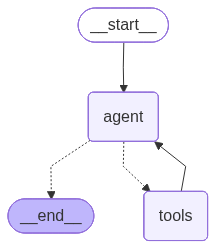

In [5]:
workflow = StateGraph(AgentState)

# Add the nodes
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Set the entry point
workflow.add_edge(START, "agent")

# Add conditional edges (The loop logic)
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

# Tools always go back to the agent to process the result
workflow.add_edge("tools", "agent")

# Compile the graph
app = workflow.compile()

# Visualizing the Graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed. (Ensure pygraphviz or mermaid is available)")

## 8. Executing the Agent
Let's see the state machine in action. It will Think (Agent) -> Action (Tools) -> Observe (Agent) -> Output (End).

In [6]:
query = "What is the weather in Paris?"
inputs = {"messages": [HumanMessage(content=query)]}

for chunk in app.stream(inputs, stream_mode="values"):
    message = chunk["messages"][-1]
    # Use hasattr to check for content because some internal messages might differ
    if hasattr(message, "content"):
        print(f"--- {type(message).__name__} ---")
        print(message.content or "[Tool Call]")

--- HumanMessage ---
What is the weather in Paris?
--- AIMessage ---
[Tool Call]
--- ToolMessage ---
It's sunny and 22°C in Paris.
--- AIMessage ---
It's sunny and 22°C in Paris.


## 9. Conclusion: The Single Agent Machine
We have transformed our linear logic into a structured state machine. This approach is superior because:
1. **Traceability**: We can see exactly which node produced which part of the answer.
2. **Extensibility**: In the next notebook, adding a "Reviewer" agent is as simple as adding a second node and a new edge.
3. **Resilience**: If a tool fails, we can add an edge that goes back to the agent to try again.

**Pro-Tip**: LangGraph's use of `Annotated` for state updates means you never have to worry about manually managing the `chat_history` variable again!

---